# Partial transpose order parameter check
Created 03/24/2026

Objectives:
* Check Pollman's TRS order parameter on transverse field cluster states.

# Package imports

In [1]:
import sys
sys.path.append("../..")

In [15]:
from functools import reduce
from itertools import combinations

In [2]:
import h5py
from tenpy.tools import hdf5_io
import tenpy
import tenpy.linalg.np_conserved as npc

import os

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
from SPTOptimization.SymmetryActionWithBoundaryUnitaries import SymmetryActionWithBoundaryUnitaries
from SPTOptimization.Optimizers.utils import one_site_optimization

from SPTOptimization.gradients import expectation_gradient_from_environments_and_b_tensor

In [14]:
import quimb as qu
import quimb.tensor as qtn

/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:54: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(
/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:36: UserWarning: Couldn't import `kahypar` - skipping from default hyper optimizer and using basic `labels` method instead.
  warnings.warn(
/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:73: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(


# Load data

In [6]:
DATA_DIR = r"../../data/transverse_cluster_200_site_dmrg"

In [7]:
loaded_data = list()

for local_file_name in os.listdir(DATA_DIR):
    f_name = r"{}/{}".format(DATA_DIR, local_file_name, ignore_unknown=False)
    with h5py.File(f_name, 'r') as f:
        data = hdf5_io.load_from_hdf5(f)
        loaded_data.append(data)

In [8]:
b_parameters = sorted(list(d['paramters']['B'] for d in loaded_data))

In [19]:
def get_quimb_mps(tenpy_mps):
    psi_arrays = list()
    psi_arrays.append(tenpy_mps.get_B(0, 'Th')[0, ...].to_ndarray())
    for i in range(1, tenpy_mps.L-1):
        psi_arrays.append(tenpy_mps.get_B(i).to_ndarray())
    psi_arrays.append(tenpy_mps.get_B(tenpy_mps.L-1)[..., 0].to_ndarray())
    
    out = (
        qtn
        .tensor_1d
        .MatrixProductState(psi_arrays, shape='lpr')
    )

    return out

In [20]:
psi_dict = dict()

for b in b_parameters:
    psi = next(
        d['wavefunction']
        for d in loaded_data
        if d['paramters']['B'] == b
    )

    rounded_b = round(b, 1)
    psi_dict[rounded_b] = get_quimb_mps(psi)

# Definitions

In [11]:
np_I = np.array([[1,0],[0,1]])
np_X = np.array([[0,1],[1,0]])
np_Y = np.array([[0,-1j],[1j,0]])
np_Z = np.array([[1,0],[0,-1]])

In [12]:
symmetry_actions = [
    [np_I, np_I],
    [np_I, np_X],
    [np_X, np_I],
    [np_X, np_X]
]

In [13]:
symmetry_labels = [
    'II',
    'IX',
    'XI',
    'XX'
]

# First iteration

In [74]:
test_psi = psi_dict[0.0]

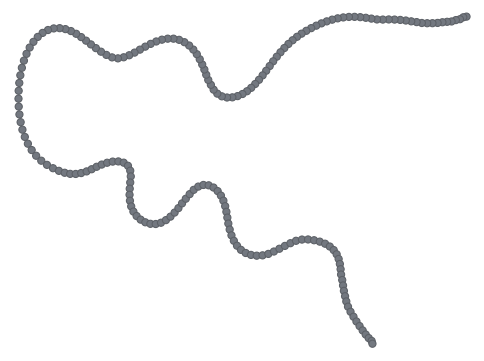

In [75]:
test_psi.draw()

In [76]:
test_psi.conj()

MatrixProductState(tensors=200, indices=399, L=200, max_bond=2)

In [100]:
num_sites = 3

In [101]:
test_rho = test_psi.partial_trace_to_mpo(
    list(range(100-num_sites, 100+num_sites))
)

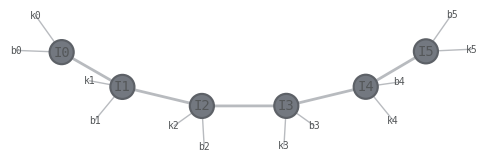

In [102]:
test_rho.draw()

In [103]:
test_rho

MatrixProductOperator(tensors=6, indices=17, L=6, max_bond=4)

In [104]:
test_rho_pt = test_rho.partial_transpose(
    list(range(100-num_sites, 100+num_sites)),
    inplace=False
)

In [105]:
test_rho_pt

MatrixProductOperator(tensors=6, indices=17, L=6, max_bond=4)

In [106]:
test_rho_2 = test_rho.copy()

In [107]:
test_rho_2.reindex(
    {f'{s}{i}': f'{s}{i}_2' for s in ['k', 'b'] for i in range(2*num_sites)},
    inplace=True
)

MatrixProductOperator(tensors=6, indices=17, L=6, max_bond=4)

In [108]:
test_rho_2

MatrixProductOperator(tensors=6, indices=17, L=6, max_bond=4)

In [109]:
test_rho.reindex(
    {f'{s}{i}': f'{s}{i}_1' for s in ['k', 'b'] for i in range(2*num_sites)},
    inplace=True
)

MatrixProductOperator(tensors=6, indices=17, L=6, max_bond=4)

In [110]:
test_rho

MatrixProductOperator(tensors=6, indices=17, L=6, max_bond=4)

In [111]:
x_gate = qtn.Tensor(data=np_X, inds=('b', 'k'))

In [112]:
x_gate

Tensor(shape=(2, 2), inds=('b', 'k'), tags=oset([]))

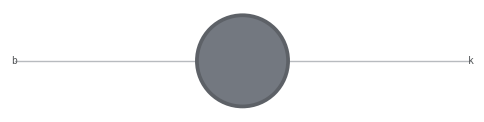

In [113]:
x_gate.draw()

In [114]:
x_gates_b = [
    x_gate.copy().reindex({'b': f'b{i}_1', 'k': f'b{i}_2'})
    for i in range(num_sites)
]

x_gates_k = [
    x_gate.copy().reindex({'b': f'k{i}_1', 'k': f'k{i}_2'})
    for i in range(num_sites)
]

In [115]:
len(x_gates_b)

3

In [116]:
x_gates_b

[Tensor(shape=(2, 2), inds=('b0_1', 'b0_2'), tags=oset([])),
 Tensor(shape=(2, 2), inds=('b1_1', 'b1_2'), tags=oset([])),
 Tensor(shape=(2, 2), inds=('b2_1', 'b2_2'), tags=oset([]))]

In [117]:
x_gates_k

[Tensor(shape=(2, 2), inds=('k0_1', 'k0_2'), tags=oset([])),
 Tensor(shape=(2, 2), inds=('k1_1', 'k1_2'), tags=oset([])),
 Tensor(shape=(2, 2), inds=('k2_1', 'k2_2'), tags=oset([]))]

In [118]:
(
    test_rho_2
    .reindex(
        {f'k{i}_2': f'b{i}_1' for i in range(num_sites, 2*num_sites)},
        inplace=True
    )
    .reindex(
        {f'b{i}_2': f'k{i}_1' for i in range(num_sites, 2*num_sites)},
        inplace=True
    )
)

MatrixProductOperator(tensors=6, indices=17, L=6, max_bond=4)

In [119]:
test_rho_2

MatrixProductOperator(tensors=6, indices=17, L=6, max_bond=4)

In [120]:
final = qtn.tensor_core.TensorNetwork(
    [
        test_rho,
        test_rho_2,
        *x_gates_b,
        *x_gates_k
    ]
)

In [126]:
final

TensorNetwork(tensors=18, indices=28)

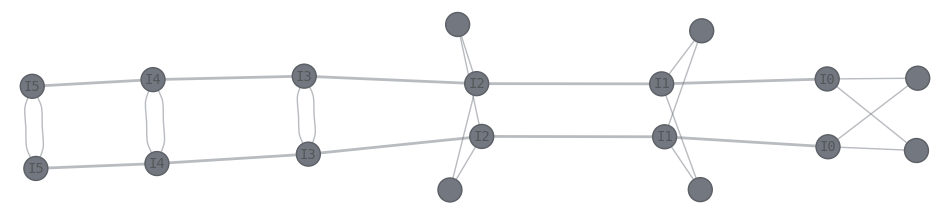

In [125]:
final.draw(show_inds=True, figsize=(12, 8))

# Run and sweep

In [ ]:
x_gate = qtn.Tensor(data=np_X, inds=('b', 'k'))

In [132]:
def trs_order_parameter(psi, num_sites=20):
    rho = psi.partial_trace_to_mpo(
        list(range(100-num_sites, 100+num_sites))
    )

    rho_2 = rho.copy()

    rho.reindex(
        {f'{s}{i}': f'{s}{i}_1' for s in ['k', 'b'] for i in range(2*num_sites)},
        inplace=True
    )
    
    rho_2.reindex(
        {f'{s}{i}': f'{s}{i}_2' for s in ['k', 'b'] for i in range(2*num_sites)},
        inplace=True
    )

    x_gates_b = [
        x_gate.copy().reindex({'b': f'b{i}_1', 'k': f'b{i}_2'})
        for i in range(num_sites)
    ]
    
    x_gates_k = [
        x_gate.copy().reindex({'b': f'k{i}_1', 'k': f'k{i}_2'})
        for i in range(num_sites)
    ]

    (
        rho_2
        .reindex(
            {f'k{i}_2': f'b{i}_1' for i in range(num_sites, 2*num_sites)},
            inplace=True
        )
        .reindex(
            {f'b{i}_2': f'k{i}_1' for i in range(num_sites, 2*num_sites)},
            inplace=True
        )
    )

    final = qtn.tensor_core.TensorNetwork(
        [
            rho,
            rho_2,
            *x_gates_b,
            *x_gates_k
        ]
    )

    out = final.contract()

    return out

In [134]:
trs_order_parameters = [
    trs_order_parameter(psi) for psi in psi_dict.values()
]

In [135]:
b_strengths = list(psi_dict.keys())

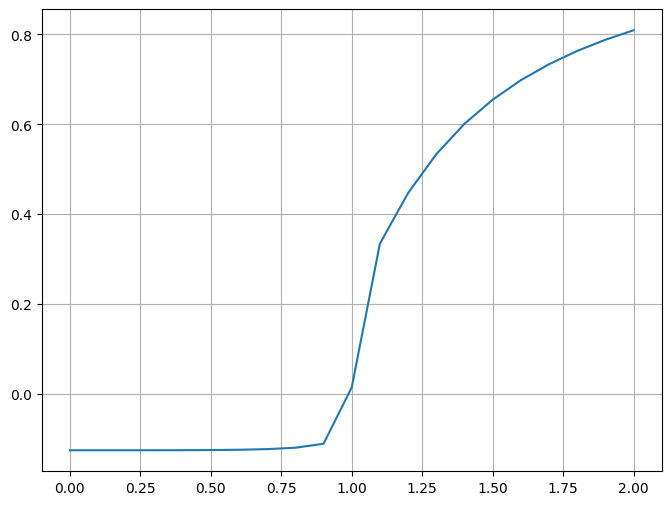

In [137]:
fig, ax = plt.subplots(figsize=(8,6))

ax.plot(b_strengths, trs_order_parameters)
ax.grid()

# Conclusions
That's what we expected!